In [1]:
%load_ext autoreload
%autoreload 2

import plotting as plt

from data_utils import load_or_create_vocabulary
from train      import run_training
from inference  import reconstruct_smiles_table
import os
import data_utils as du

In [2]:
cfg = dict(
    # ---------------- data ----------------
    train_files = [
        "/home/mmondol/VAE_LLM/Data/Train_1.csv",
        "/home/mmondol/VAE_LLM/Data/Train_2.csv",
        "/home/mmondol/VAE_LLM/Data/Train_3.csv"],
    val_files   = ["/home/mmondol/VAE_LLM/Data/Valid_1.csv"],
    test_files  = ["/home/mmondol/VAE_LLM/Data/Test.csv"],
    dye_csv     = ["/home/mmondol/VAE_LLM/Data/dye.csv"],
    seq_length  = 160,
    n_train     = 250000,   # number of training examples
    n_val       = 80000,    # number of validation examples

    # ---------------- model ----------------
    d_model     = 256,
    latent_dim  = 64,   # latent dimension
    enc_layers  = 7,
    dec_layers  = 7,
    dropout     = 0.05,
    emb_dropout = 0.05,

    # special token indices (match your vocabulary)
    pad_idx     = 0,
    sos_idx     = 2,
    eos_idx     = 3,

    # -------------- optimization --------------
    batch       = 128,
    lr          = 1e-4,
    weight_decay= 1e-4,
    epochs      = 50,
    early_stop  = 10,
    early_stop_min_delta = 1e-4,
    clip_grad   = 1.0,

    # -------------- schedules --------------
    kl_anneal   = 15,
    kl_max      = 0.02,

    # -------- regularization tweaks --------
    label_smoothing = 0.02,   # 0.0 to disable
    corruption_p     = 0.05,  # word-dropout on decoder inputs (train only)

    # -------- validation / decoding --------
    greedy_every  = 5,   # run beam metrics every N epochs

    # ---------------- I/O ----------------
    save_dir    = "./checkpoints",
    save_every  = 10,   # periodic checkpointing

    # -------- (optional) LR scheduler ------
    plateau = dict(mode="min", factor=0.3, patience=3, verbose=True, min_lr=0.0, threshold=1e-4),
)

In [3]:
all_csvs = cfg["train_files"] + cfg["val_files"] + cfg["test_files"]
token_to_idx, idx_to_token = load_or_create_vocabulary(all_csvs, cache_path="vocab.json", test_smiles=None)

assert token_to_idx["<PAD>"] == cfg["pad_idx"], "PAD index mismatch with cached vocab"
assert token_to_idx["<SOS>"] == cfg["sos_idx"], "SOS index mismatch with cached vocab"
assert token_to_idx["<EOS>"] == cfg["eos_idx"], "EOS index mismatch with cached vocab"
print("Vocab size:", len(token_to_idx))
print(token_to_idx)
print("Special tokens:")
print("PAD:", token_to_idx["<PAD>"])
print("SOS:", token_to_idx["<SOS>"])
print("EOS:", token_to_idx["<EOS>"])

[vocab] loaded cached vocabulary from vocab.json (69 tokens)
Vocab size: 69
{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, 'O': 4, '=': 5, 'C': 6, '1': 7, 'N': 8, '[C@@H]': 9, '[NH+]': 10, '(': 11, 'c': 12, '2': 13, '(O)': 14, ')': 15, '(=O)': 16, 'S': 17, '3': 18, 'n': 19, '-': 20, '[C@H]': 21, '4': 22, 's': 23, '(C)': 24, '[': 25, ']': 26, '(F)': 27, 'F': 28, '#': 29, '[nH]': 30, '[nH+]': 31, '(Cl)': 32, 'o': 33, '[NH2+]': 34, '@': 35, 'H': 36, '+': 37, '(Br)': 38, '[O-]': 39, 'Cl': 40, '[N-]': 41, '/': 42, '\\': 43, 'Br': 44, '5': 45, '(I)': 46, 'I': 47, '6': 48, '[N+]': 49, '[n+]': 50, '[o+]': 51, '7': 52, 'p': 53, '.': 54, 'P': 55, '8': 56, '9': 57, 'A': 58, 'B': 59, '[Na+]': 60, '[Zn]': 61, '[Co+2]': 62, '[Cd+2]': 63, '[Cl-]': 64, '[Cr+3]': 65, '[B-]': 66, '[C+]': 67, '[Pb+2]': 68}
Special tokens:
PAD: 0
SOS: 2
EOS: 3


In [4]:
model, history = run_training(cfg, token_to_idx, idx_to_token)

Using device: cuda
Visible CUDA devices: 1


/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:165: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch  1: train 1.7790/0.513  val(tf) 1.1687/0.652  KL 0.001
Epoch  2: train 1.2120/0.668  val(tf) 0.8414/0.743  KL 0.003
Epoch  3: train 0.9863/0.734  val(tf) 0.6226/0.806  KL 0.004
Epoch  4: train 0.8303/0.784  val(tf) 0.4869/0.847  KL 0.005
Epoch  5: train 0.7179/0.822  val(tf) 0.4033/0.875  greedy_acc 0.628  valid 0.402  lev 12.33  nov 0.999  KL 0.007
Epoch  6: train 0.6316/0.853  val(tf) 0.3175/0.909  KL 0.008
Epoch  7: train 0.5634/0.879  val(tf) 0.2510/0.934  KL 0.009
Epoch  8: train 0.5068/0.901  val(tf) 0.2319/0.941  KL 0.011
Epoch  9: train 0.4628/0.918  val(tf) 0.1720/0.963  KL 0.012
Epoch 10: train 0.4279/0.932  val(tf) 0.1564/0.968  greedy_acc 0.877  valid 0.753  lev 4.12  nov 1.000  KL 0.013
Epoch 11: train 0.4011/0.943  val(tf) 0.1544/0.970  KL 0.015
Epoch 12: train 0.3798/0.951  val(tf) 0.1311/0.978  KL 0.016
Epoch 13: train 0.3624/0.958  val(tf) 0.1219/0.982  KL 0.017
Epoch 14: train 0.3486/0.964  val(tf) 0.1156/0.985  KL 0.019
Epoch 15: train 0.3378/0.968  val(tf) 0.1

[plot] saved to ./checkpoints/training_curves.png


(<Figure size 1500x800 with 6 Axes>,
 array([[<Axes: title={'center': 'Loss'}, ylabel='CE+KL'>,
         <Axes: title={'center': 'Token level Acc'}>,
         <Axes: title={'center': 'Validation accuracy with beam search'}>],
        [<Axes: title={'center': 'Validity Ratio'}, xlabel='epoch'>,
         <Axes: title={'center': 'Average Levenshtein Distance'}, xlabel='epoch'>,
         <Axes: xlabel='epoch'>]], dtype=object))

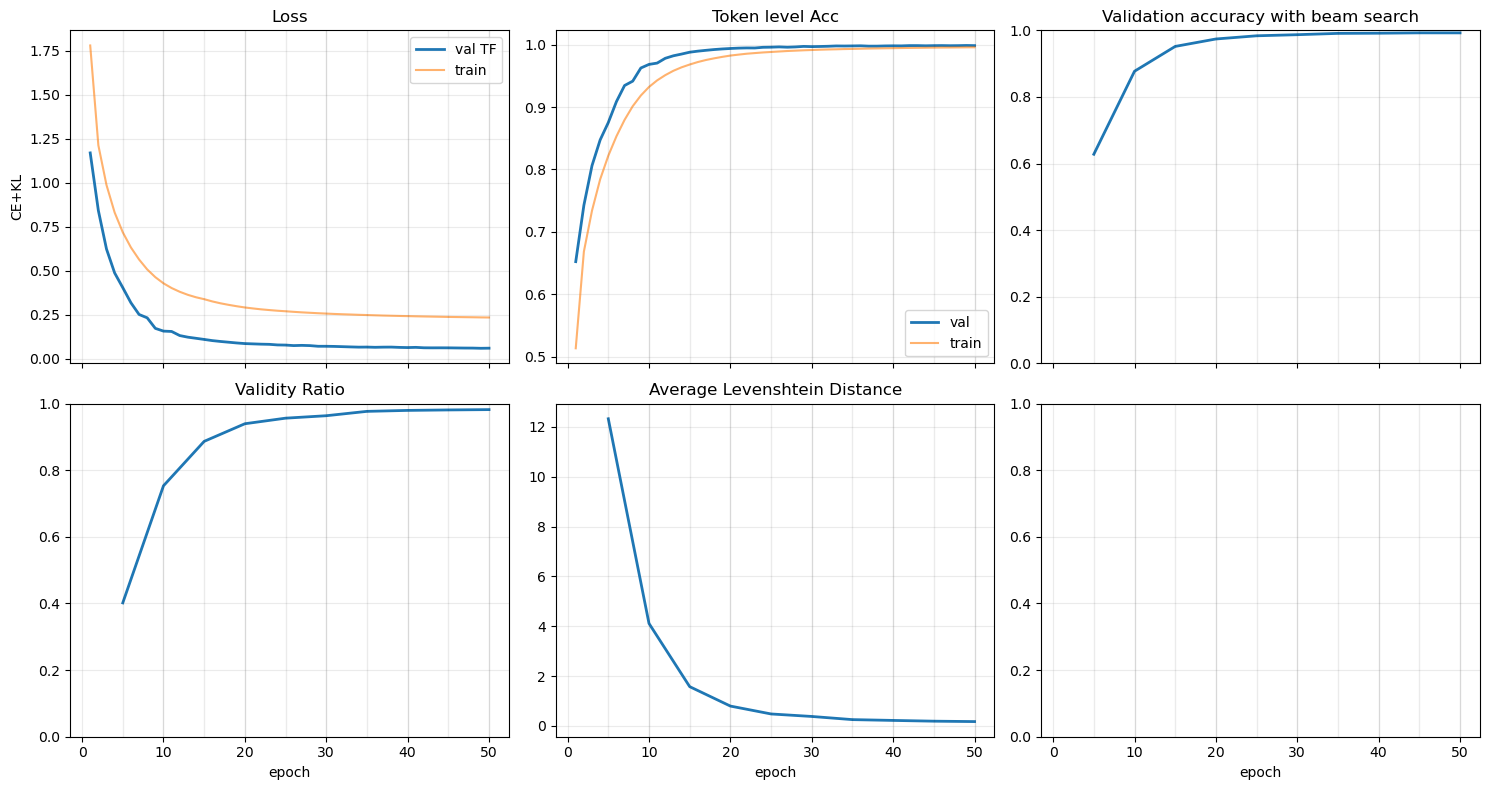

In [5]:
plt.plot_training_curves(history, metrics_every=cfg["greedy_every"], save_path=os.path.join(cfg["save_dir"], "training_curves.png"))

In [6]:
import torch, torch.nn as nn

device = next(model.parameters()).device

df_rec = reconstruct_smiles_table(
    smiles_list=None,
    test_csv=cfg["test_files"][0],
    model=model,
    token_to_idx=token_to_idx,
    idx_to_token=idx_to_token,
    seq_length=cfg["seq_length"],
    pad_idx=cfg["pad_idx"],
    sos_idx=cfg["sos_idx"],
    eos_idx=cfg["eos_idx"],
    device=device,
    max_len = None)

df_rec.tail(20)

,input,reconstructed,valid,lev
250,CC(C)=CC(=O)NCc1cc[nH+]c(N2CCO[C@@H](C)C2)c1,CC(C)=CC(=O)NCc1cc[nH+]c(N2CCO[C@@H](C)C2)c1,yes,0
251,[NH3+]CC1([C@H](O)c2ccccc2OC(F)F)CCC1,[NH3+]CC1([C@H](O)c2ccccc2OC(F)F)CCC1,yes,0
252,COC(=O)c1nn(CC(=O)NCCc2ccc(OC)c(OC)c2)c(=O)c2n...,COC(=O)c1nn(CC(=O)NCCc2ccc(OC)c(OC)c2)c(=O)c2n...,yes,0
253,Cc1cnc(NC(=O)N[C@@H](C)c2ccc(S(=O)(=O)N(C)C)cc...,Cc1cnc(NC(=O)N[C@@H](C)c2ccc(S(=O)(=O)N(C)C)cc...,yes,0
254,CCOC(=O)c1cnn([C@H]2CCCN(C(=O)Nc3cccc(N(C)CC)c...,CCOC(=O)c1cnn([C@H]2CCCN(C(=O)Nc3cccc(N(C)CC)c...,yes,0
255,CCCCNC(=O)[C@H]1[C@H]2C=C[C@]3(CN(c4cc(C)on4)C...,CCCCNC(=O)[C@H]1[C@H]2C=C[C@]3(CN(c4cc(C)on4)C...,yes,0
256,CC(C)[C@@H]1CN(Cc2c[nH]nc2-c2ccc(Cl)cc2)C[C@H]...,CC(C)[C@@H]1CN(Cc2c[nH]nc2-c2ccc(Cl)cc2)C[C@H]...,yes,0
257,CC(C)N(Cc1ccc(Cl)nc1)C[C@H]1CCCCO1,CC(C)N(Cc1ccc(Cl)nc1)C[C@H]1CCCCO1,yes,0
258,c1ccc(-c2nc(CN3CCC[C@H]3c3ccccc3)no2)cc1,c1ccc(-c2nc(CN3CCC[C@H]3c3ccccc3)no2)cc1,yes,0
259,CC(C)C[C@@H](CN)C(=O)NCCCC(=O)[O-],CC(C)C[C@@H](CN)C(=O)NCCCC(=O)[O-],yes,0


In [7]:

# ------------------------------------------------------------------
# 1.  Token-level accuracy (micro-average over SMILES tokens)
# ------------------------------------------------------------------
def token_accuracy_row(gold, pred):
    g = du.tokenize_smiles(gold)
    p = du.tokenize_smiles(pred)
    L = min(len(g), len(p))
    if L == 0:                      # degenerate empty case
        return 0, 0
    correct = sum(gi == pi for gi, pi in zip(g[:L], p[:L]))
    total   = L
    return correct, total

tot_corr = tot_tok = 0
for g, p in zip(df_rec["input"], df_rec["reconstructed"]):
    c, t = token_accuracy_row(g, p)
    tot_corr += c
    tot_tok  += t

beam_token_acc = tot_corr / tot_tok if tot_tok else 0.0
print(f"Token level test accuracy (beam): {beam_token_acc:.4f}")

# ------------------------------------------------------------------
# 2.  Sequence-level (exact-match) accuracy
# ------------------------------------------------------------------
exact_match_acc = (df_rec["input"] == df_rec["reconstructed"]).mean()
print(f"Exact SMILES match accuracy (beam): {exact_match_acc:.4f}")

# ---- summary metrics ----
valid_ratio = (df_rec["valid"] == "yes").mean() if len(df_rec) else float("nan")
avg_lev     = df_rec["lev"].mean() if len(df_rec) else float("nan")

print(f"Greedy validity ratio: {valid_ratio:.3f}")
print(f"Greedy average Levenshtein: {avg_lev:.3f}")

Token level test accuracy (beam): 0.9958
Exact SMILES match accuracy (beam): 0.9667
Greedy validity ratio: 0.989
Greedy average Levenshtein: 0.144


In [8]:
df_rec = reconstruct_smiles_table(
    smiles_list=None,
    test_csv=cfg["dye_csv"][0],
    model=model,
    token_to_idx=token_to_idx,
    idx_to_token=idx_to_token,
    seq_length=cfg["seq_length"],
    pad_idx=cfg["pad_idx"],
    sos_idx=cfg["sos_idx"],
    eos_idx=cfg["eos_idx"],
    device=device)

df_rec.head(20)

,input,reconstructed,valid,lev
0,O=S1(=O)OC(c2ccc(O)c(Cl)c2)(c2ccc(O)c(Cl)c2)c2...,O=S1(=O)OC(c2ccc(O)c(Cl)c2)(c2ccc(O)c(Cl)c2)c2...,yes,0
1,O=S1(=O)OC(c2ccc(O)c(Br)c2)(c2ccc(O)c(Br)c2)c2...,O=S1(=O)OC(c2ccc(O)c(Br)c2)(c2ccc(O)c(Br)c2)c2...,yes,0
2,Cc1cc(C2(c3cc(C)c(O)c(Br)c3)OS(=O)(=O)c3ccccc3...,Cc1cc(C2(c3cc(C)c(O)c(Br)c3)SS(=O)(=O)c3ccccc3...,yes,1
3,O=S1(=O)OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,O=S1(=O)OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,yes,0
4,Cc1cc(O)ccc1C1(c2ccc(O)cc2C)OS(=O)(=O)c2ccccc21,Cc1cc(O)ccc1C1(c2ccc(O)cc2C)OS(=O)(=O)c2ccccc21,yes,0
5,CN(C)c1ccc(N=Nc2ccccc2)cc1,CN(C)c1ccc(NC(N)ccccc2)cc1,no,4
6,CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1,CN(C)c1ccc(NC(N)ccc(S(=O)(=O)C)cc2)cc1,no,8
7,c1ccc(-c2cc3nc4cccc(-c5ccccc5-c5ccccc5)c4nc3cc...,c1ccc(-c2cc3nc4ccc(-c5ccccc5-c5ccccc5)c4nc3cc2...,no,1
8,CN(C)c1ccc(N=Nc2ccccc2C(=O)O)cc1,CN(C)c1ccc(NC(c2ccccc2C(=O)O)cc1,no,2
9,O=C1OC2(c3ccc(O)cc3Oc3cc(O)ccc32)c2ccccc21,O=C1OC2(c3ccc(O)cc3Oc3cc(O)ccc32)c2ccccc21,yes,0


In [9]:
tot_corr = tot_tok = 0
for g, p in zip(df_rec["input"], df_rec["reconstructed"]):
    c, t = token_accuracy_row(g, p)
    tot_corr += c
    tot_tok  += t

beam_token_acc = tot_corr / tot_tok if tot_tok else 0.0
print(f"Token level test accuracy for Dye SMILES (beam): {beam_token_acc:.4f}")

# ------------------------------------------------------------------
# 2.  Sequence-level (exact-match) accuracy
# ------------------------------------------------------------------
exact_match_acc = (df_rec["input"] == df_rec["reconstructed"]).mean()
print(f"Exact SMILES match accuracy for Dye SMILES (beam): {exact_match_acc:.4f}")

# ---- summary metrics ----
valid_ratio = (df_rec["valid"] == "yes").mean() if len(df_rec) else float("nan")
avg_lev     = df_rec["lev"].mean() if len(df_rec) else float("nan")

print(f"Greedy validity ratio: {valid_ratio:.3f}")
print(f"Greedy average Levenshtein: {avg_lev:.3f}")

Token level test accuracy for Dye SMILES (beam): 0.9250
Exact SMILES match accuracy for Dye SMILES (beam): 0.5294
Greedy validity ratio: 0.824
Greedy average Levenshtein: 2.265
